# Analisis Exhaustivo de Global Forest Watch (GFW): Michoacan
## HackODS UNAM 2026 | ODS 15

Este cuaderno presenta una visualizacion multidimensional de todos los atributos procesados de GFW, desde la composicion de bosques naturales hasta las emisiones de CO2.

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import os

DATA_DIR = "data/procesados/"
print("INFO: Entorno cargado para analisis multidimensional.")

INFO: Entorno cargado para analisis multidimensional.


## 1. Composicion del Ecosistema Forestal (SBTN)
¿Que tipo de bosques estamos tratando de proteger? Este grafico muestra la clasificacion de bosques naturales en el estado.

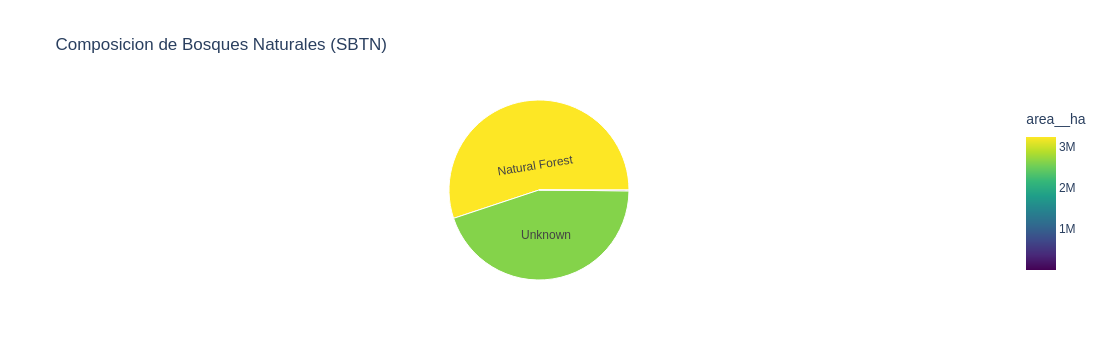

In [2]:
df_nat = pd.read_csv(os.path.join(DATA_DIR, "gfw_clases_bosque_natural.csv"))
fig_sun = px.sunburst(
    df_nat, 
    path=['sbtn_natural_forests__class'], 
    values='area__ha',
    title="Composicion de Bosques Naturales (SBTN)",
    color='area__ha',
    color_continuous_scale='Viridis'
)
fig_sun.show()

## 2. Los Motores de la Deforestacion
Visualizacion dinamica de los factores que causan la perdida de cobertura arborea año con año.

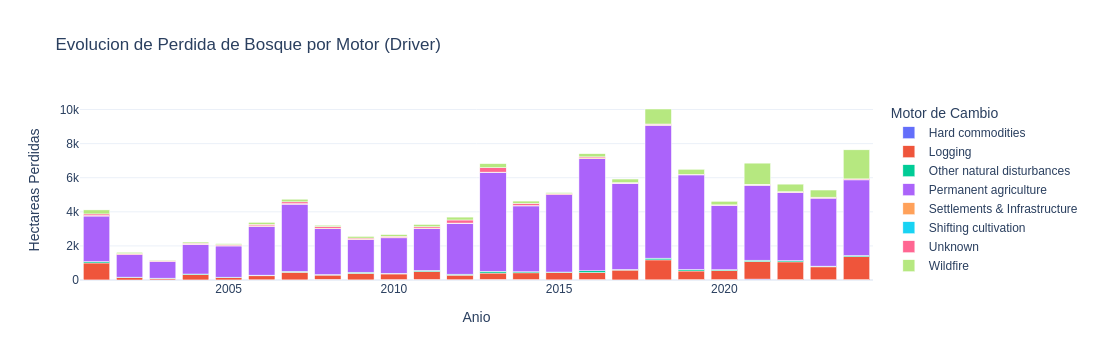

In [3]:
df_drivers = pd.read_csv(os.path.join(DATA_DIR, "gfw_drivers_perdida_completo.csv"))
fig_bar = px.bar(
    df_drivers, 
    x="loss_year", 
    y="loss_area_ha", 
    color="drivers_type",
    title="Evolucion de Perdida de Bosque por Motor (Driver)",
    labels={'loss_year': 'Anio', 'loss_area_ha': 'Hectareas Perdidas', 'drivers_type': 'Motor de Cambio'},
    template="plotly_white"
)
fig_bar.show()

## 3. El Costo Climatico: Emisiones de CO2
La deforestacion no solo es perdida de arboles; es la liberacion masiva de carbono a la atmosfera.

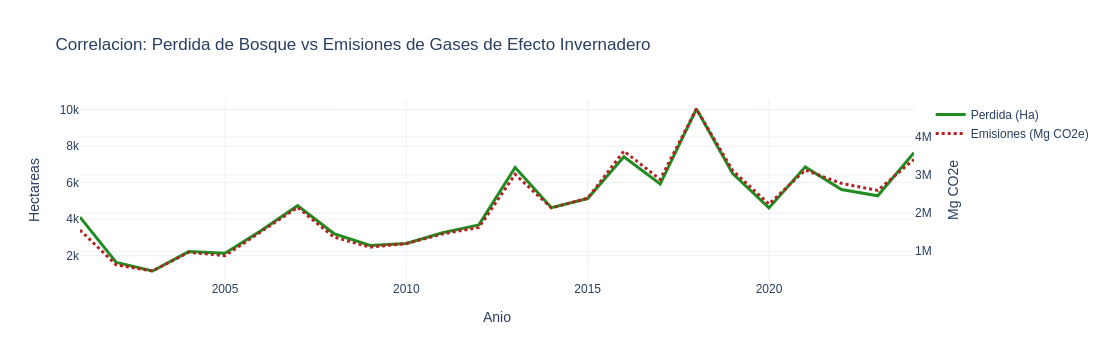

In [4]:
df_loss = pd.read_csv(os.path.join(DATA_DIR, "gfw_historico_perdida_emisiones.csv"))
fig_emissions = go.Figure()

fig_emissions.add_trace(go.Scatter(
    x=df_loss['umd_tree_cover_loss__year'], 
    y=df_loss['umd_tree_cover_loss__ha'],
    name="Perdida (Ha)", 
    line=dict(color='forestgreen', width=3)
))

fig_emissions.add_trace(go.Scatter(
    x=df_loss['umd_tree_cover_loss__year'], 
    y=df_loss['gfw_gross_emissions_co2e_all_gases__Mg'],
    name="Emisiones (Mg CO2e)", 
    yaxis="y2",
    line=dict(color='firebrick', width=3, dash='dot')
))

fig_emissions.update_layout(
    title="Correlacion: Perdida de Bosque vs Emisiones de Gases de Efecto Invernadero",
    xaxis_title="Anio",
    yaxis_title="Hectareas",
    yaxis2=dict(title="Mg CO2e", overlaying="y", side="right"),
    template="plotly_white"
)
fig_emissions.show()

## 4. Panorama Municipal: Extension vs Cobertura Base
Analisis de la proporcion de bosque por municipio en 2010.

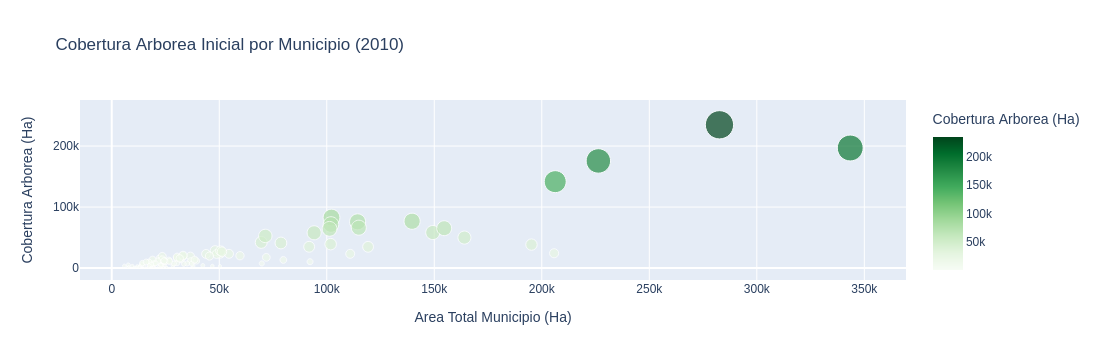

In [5]:
df_mun = pd.read_csv(os.path.join(DATA_DIR, "gfw_cobertura_municipal_2010.csv"))
fig_bubble = px.scatter(
    df_mun, 
    x="area__ha", 
    y="umd_tree_cover_extent_2010__ha", 
    size="umd_tree_cover_extent_2010__ha",
    hover_name="municipio",
    title="Cobertura Arborea Inicial por Municipio (2010)",
    labels={'area__ha': 'Area Total Municipio (Ha)', 'umd_tree_cover_extent_2010__ha': 'Cobertura Arborea (Ha)'},
    color="umd_tree_cover_extent_2010__ha",
    color_continuous_scale='Greens'
)
fig_bubble.show()